# CC3001 Otoño 2026 Tarea 4 Vicente Fernández
# Cálculo de derivadas de fórmulas representadas mediante árboles

El objetivo de esta tarea es aprender a procesar la información de árboles que representan fórmulas. Hay muchas cosas que uno puede hacer con estos árboles, y en esta tarea nos enfocaremos en particular en calcular la derivada de una fórmula respecto de una variable dada.

Específicamente, el problema es: dado un árbol que representa una fórmula, construir y retornar otro árbol que representa la derivada de la primera fórmula respecto de una variable dada.

La fórmula se entrega en notación de infijo (normal). En esta fórmula,
los operadores de menor prioridad son la suma (``+``) y la resta (``-``), de igual prioridad entre sí, luego vienen la multiplicación (``*``) y la división (``/``), también de igual prioridad entre sí, y finalmente el operador de mayor prioridad es la elevación a potencia (``^``). También se puede usar paréntesis. Para simplificar no usaremos el operador "menos unario". **Nota importante**: Para no complicar excesivamente las cosas, supondremos que en la elevación a potencia el exponente no contiene la variable respecto de la cual se está derivando.

A continuación usted encontrará las clases ``Nodoi``, ``Nodoe`` y ``Arbol`` que implementan árboles que representan fórmulas. La clase ``Arbol`` viene con un constructor que recibe un string como parámetro, el cual contiene una fórmula, y este constructor se encarga de transformar la fórmula de string a árbol, de modo que usted no necesita preocuparse de eso. Para simplificar, la fórmula solo podrá contener variables de una sola letra, números de un solo dígito, y sin espacios.

Usted tiene que implementar para la clase ``Arbol`` y para los nodos una función ``derivada`` que al ser invocada indicando el nombre de una variable, retorne un árbol que represente la derivada de la fórmula respectiva.

En este enunciado vienen funciones ``derivada`` triviales, que simplemente retornan la misma fórmula, sin derivarla. Usted debe reemplazarlas por la implementación correcta


In [2]:
!pip install aed-utilities


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import aed_utilities as aed

class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der
    def postorden(self):
        self.izq.postorden()
        self.der.postorden()
        print(self.info, end=" ")
    
    def formula(self):
        return '('+self.izq.formula()+self.info+self.der.formula()+')'

    def derivada(self,x):
        # Nodo interno contiene las operaciones: +,-,*,... entonces deolver algo según el caso
        if (self.info == '^'):
            # se obtienen parámetros y se devuelve fórmula n*x^{n-1}*x'
            n = int(self.der.info)
            exp = str(n-1)
            f_prima = self.izq.derivada(x)

            return '('+str(n)+'*(x^('+exp+'))*'+f_prima+')'

        elif (self.info=='*'):
            # se pueden tener fórmulas entonces se necesita llevarlas a string, si no, se devuelve el operador en .info
            # se implementa funcion en clase para devolver formula: formula()
            f_prima = self.izq.derivada(x)
            f = self.izq.formula()
            g_prima = self.der.derivada(x)
            g = self.der.formula()

            # entrega la formula f'g+fg'
            return '('+f_prima+'*'+g+'+'+f+'*'+g_prima+')'

        elif(self.info=='/'):
            # se calculan parametros y luego se retorna con formula (f'*g)-(f*g') / g^2
            # para este caso es necesario tener toda la sub-fórmula, si no solo se devuelve el operador
            f_prima = self.izq.derivada(x)
            g_prima = self.der.derivada(x)
            f = self.izq.formula()
            g = self.der.formula()

            return '(('+f_prima+'*'+g+')-('+f+'*'+g_prima+'))/('+g+'^2)'

        # para +,- es solamente aplicar en los nodos hijos
        elif (self.info == '+'):
            return '('+self.izq.derivada(x)+'+'+self.der.derivada(x)+')'
        elif (self.info == '-'):
            return '('+self.izq.derivada(x)+'-'+self.der.derivada(x)+')'

class Nodoe:
    def __init__(self, info):
        self.info=info
    def postorden(self):
        print(self.info, end=" ")

    def formula(self):
        return self.info
    def derivada(self,x):
        # Nodos externos tienen constantes c/r a la variable o la misma variable.
        if (self.info == 'x'):
            return '1'
        else:
            return '0'
        print('error en nodo externo')

class Arbol:
    def __init__(self,formula):
        if type(formula)!=str: # se supone que viene el árbol ya construído
          self.raiz=formula
          return

        # la fórmula viene en forma de string
        global k
        global s
        s=formula+";" # agregamos una marca de fin de la entrada
        k=0 # indica próximo caracter por procesar
        # definimos funciones para analizar la fórmula
        def expresion(): # retorna puntero a la raíz de un árbol que representa a la fórmula s
            global k
            global s
            a=factor()
            while s[k]=="+" or s[k]=="-":
                op=s[k]
                k+=1
                b=factor()
                a=Nodoi(a,op,b)
            return a
        def factor():
            global k
            global s
            a=termino()
            while s[k]=="*" or s[k]=="/":
                op=s[k]
                k+=1
                b=termino()
                a=Nodoi(a,op,b)
            return a
        def termino():
            global k
            global s
            a=primario()
            if s[k]=="^":
                op=s[k]
                k+=1
                b=termino()
                a=Nodoi(a,op,b)
            return a
        def primario(): # posible constante, variable o formula parentizada
            global k
            global s
            if s[k].isalpha() or s[k].isdigit():
                a=Nodoe(s[k])
                k+=1
                return a
            if s[k]=="(": # fórmula parentizada
                k+=1
                a=expresion()
                if s[k]!=")":
                    print("Error: Falta cierra paréntesis: "+formula[k:])
                    assert False
                k+=1
                return a
            print("Error: Falta variable, número o abre paréntesis: "+formula[k:])
            assert False

        a=expresion()
        if s[k]!=";":
            print("Error: Basura al final de la fórmula: "+formula[k:])
            assert False
        self.raiz=a

    def derivada(self,x):
        return Arbol(self.raiz.derivada(x))

    def dibujar(self):
      btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der",classNone=Nodoe )
      btd.draw_tree(self, "raiz")


A continuación probamos esta funcionalidad con varias fórmulas de ejemplo. Para ver si el árbol fue construido correctamente, lo dibujaremos, y también dibujaremos el árbol resultante después del cálculo de la derivada.

In [34]:
def probar_derivada(formula,x):
    f=Arbol(formula)
    print("Fórmula original:")
    f.dibujar()
    g=f.derivada(x)
    print("Derivada respecto de "+x+":")
    g.dibujar()

Fórmula original:


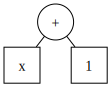

Derivada respecto de x:


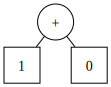

In [35]:
probar_derivada("x+1","x")

Fórmula original:


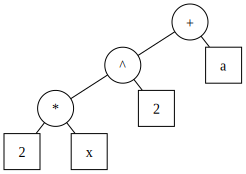

Derivada respecto de x:


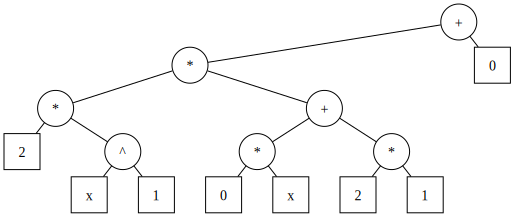

In [36]:
probar_derivada("(2*x)^2+a","x")

Fórmula original:


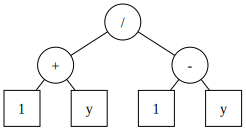

Derivada respecto de y:


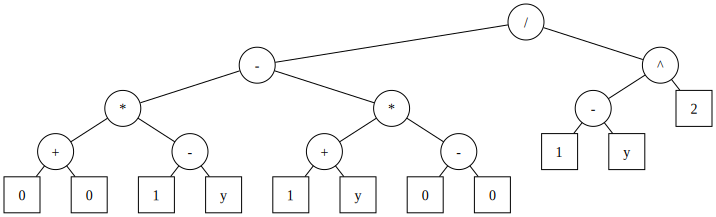

In [37]:
probar_derivada("(1+y)/(1-y)","y")

## Simplificaciones

Como habrá visto, las fórmulas resultantes no son muy sencillas, pero también es obvio que se se podrían simplificar para que quedaran mucho más presentables. A continuación, proponga y describa cómo podrían implementarse algunas simplificaciones. Piense recursivamente. No es necesario que las implemente, pero si se atreve, agregue un método ``simplificar`` y pruébelo dibujando el árbol resultante.
____

Para simplificar la fórmula resultante se podrían agregar métodos de operación para las fórmulas triviales, pues se tienen muchas operaciones que entregan 0 o con neutros aditivos y multiplcativo.

Una idea es implementar en post orden la simplificación de fórmulas triviales. En clase se vió la utilización de pilas para este propósito: se recorre el árbol en postorden y se van agregando los valores a la pila. Cuando se agrega un operador, se realiza tal operación con los valores almacenados. Se puede implementar de forma que si se detecta una operación trivial, por ejemplo para 0,0,+, no se agregue dicha operación al nuevo árbol y se les hiciese pop(). Finalmente, los elementos restantes en la pila se van agregando a un árbol utilizando el mismo método que se utilizó en esta tarea.